In [2]:
import ee
import os
import json
import pandas as pd
import geopandas as gpd
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np


In [3]:
PROJECT_ROOT = Path().resolve().parent

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

True

In [47]:
ee.Authenticate()


True

In [48]:
ee.Initialize(project=os.environ["EE_PROJECT"])

In [72]:
import importlib
import data_utils
import gee_utils

importlib.reload(data_utils)
importlib.reload(gee_utils)

<module 'gee_utils' from '/Users/bensutton/Projects/dissertation-code/src/gee_utils.py'>

In [73]:

sys.path.append(str(PROJECT_ROOT / "src"))

from gee_utils import create_images_for_all_locations, get_samples, export_patches, export_awei_p95_all_locations
from data_utils import make_padded_bbox_all_location, clean_labelled_data


In [51]:
# Want to upload the sites.json to ee and then create image collection for each, clip to the bbox, need to select the dates for each location
# Could save the location in the json or just use the date from the points? 

EE_PROJECT = os.environ["EE_PROJECT"]
site_fp = PROJECT_ROOT / "configs" / "sites.json"
label_fp = PROJECT_ROOT / "configs" / "labels.gpkg"
cleaned_label_fp = PROJECT_ROOT / "configs" / "cleaned_labels.gpkg"

In [36]:
clean_labelled_data(label_fp= label_fp, cleaned_label_fp = cleaned_label_fp)

Saved a cleaned version of /Users/bensutton/Projects/dissertation-code/configs/labels.gpkg as /Users/bensutton/Projects/dissertation-code/configs/cleaned_labels.gpkg


In [62]:
# test the created cleaned labels geopackage


labels_gdf = gpd.read_file(cleaned_label_fp)

RP_gdf = labels_gdf.loc[labels_gdf["location"]== "RawaPening"]
sent_image_id = RP_gdf.loc[RP_gdf["obs_date"]== "2024-08-10"]["s2_target_image_id"].unique()
print(sent_image_id)

['COPERNICUS/S2_SR_HARMONIZED/20240810T023551_20240810T025550_T49MDM']


In [14]:
print(len(labels_gdf))
labels_gdf.groupby(["location", "class_label"])["lc"].count().reset_index(name="count")

16192


,location,class_label,count
0,Hartbeespoort,LEV,509
1,Hartbeespoort,floating_plants,1002
2,Hartbeespoort,open_water,440
3,Hartbeespoort,surface_algae,81
4,Inle,LEV,500
5,Inle,floating_plants,1000
6,Inle,open_water,500
7,Mula,LEV,576
8,Mula,floating_plants,1003
9,Mula,open_water,493


In [53]:

labels_gdf.groupby(["location"])["lc"].count().reset_index(name="count")

,location,count
0,Hartbeespoort,2032
1,Inle,2000
2,Mula,2072
3,RawaPening,2004
4,Rodman,2042
5,Valsequillo,2040
6,Vembanad,2002
7,Winam,2000


In [40]:
# Make a bounding box for each site based on the total bounds of the labelled points and add a padding

make_padded_bbox_all_location(sites_file= site_fp, project_root= PROJECT_ROOT)

Created padded bbox from the points files for Vembanad, Winam, Inle, Hartbeespoort, Mula, RawaPening, Rodman, Valsequillo


In [ ]:
# Memomry limits made it neccesary to create an AWEI_p95 (with the 95th percentile for AWEIsh, 2019-2025) image that is saved to assets for each location.
# After running the code to export use the returned task list areto ensure exports are completed before running create_images_for_all_locations()

task_list = export_awei_p95_all_locations(ee_project= EE_PROJECT, sites_file= site_fp)

In [ ]:
for task in task_list:
    print(task.status())

In [63]:
image_collection = create_images_for_all_locations(sites_file= site_fp, cleaned_label_fp=cleaned_label_fp, ee_project=EE_PROJECT, clip = False)

Created image collection for: Vembanad
Created image collection for: Winam
Created image collection for: Inle
Created image collection for: Hartbeespoort
Created image collection for: Mula
Created image collection for: RawaPening
Created image collection for: Rodman
Created image collection for: Valsequillo


In [64]:
print(image_collection.first().bandNames().getInfo())

['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'AWEIp95']


In [65]:
# Due to memory limits it is not possible to convert all the sampled points to a data frame, therefore the sampled points for each location 
# is export to drive as a CSV separately


# Trying to save all without aweip95

get_samples(merged_ic=image_collection,cleaned_label_fp= cleaned_label_fp)

Exporting sampled points for Hartbeespoort to drive/Dissertation
Exporting sampled points for Mula to drive/Dissertation
Exporting sampled points for RawaPening to drive/Dissertation
Exporting sampled points for Vembanad to drive/Dissertation
Exporting sampled points for Valsequillo to drive/Dissertation
Exporting sampled points for Rodman to drive/Dissertation
Exporting sampled points for Winam to drive/Dissertation
Exporting sampled points for Inle to drive/Dissertation


In [67]:
for task in ee.batch.Task.list():
    status = task.status()
    desc = status.get("description", "")

    if desc.startswith("sampled_points_"):
        print(desc, status["state"])
        print("EECU seconds:", status.get("batch_eecu_usage_seconds"))
        if status["state"] == "FAILED":
            print(status.get("error_message"))

sampled_points_Inle COMPLETED
EECU seconds: 61.36330795288086
sampled_points_Winam COMPLETED
EECU seconds: 163.12403869628906
sampled_points_Rodman COMPLETED
EECU seconds: 35.267826080322266
sampled_points_Valsequillo COMPLETED
EECU seconds: 39.449031829833984
sampled_points_Vembanad COMPLETED
EECU seconds: 58.2348518371582
sampled_points_RawaPening COMPLETED
EECU seconds: 37.65679168701172
sampled_points_Mula COMPLETED
EECU seconds: 80.30052185058594
sampled_points_Hartbeespoort COMPLETED
EECU seconds: 47.24900436401367


In [68]:
# Load location samples from csvs in outputs/sampled_points_by_location, combine into a single dataframe and save 

samples_outpath = PROJECT_ROOT / "outputs" / "sample_points.csv"

with open(site_fp) as f:
    sites= json.load(f)

location_list = list(sites.get("sites", {}).keys())

list_of_location_dfs = []

for location in location_list:
    location_samples_fp = PROJECT_ROOT / "outputs/sampled_points_by_location/sampled_points" / f"sampled_points_{location}.csv" 

    location_df = pd.read_csv(location_samples_fp)

    list_of_location_dfs.append(location_df)

all_samples = pd.concat(list_of_location_dfs, ignore_index= True)



all_samples.to_csv(samples_outpath, index= False)



-------------------------
Some points are missing between labels.phkg ad the sampled points. Approx 170, trying to find out why

In [ ]:
# check len of inle 

inle_fp = PROJECT_ROOT / "outputs/sampled_points_by_location/sampled_points" / f"sampled_points_inle.csv"

inle_points = pd.read_csv(inle_fp)
len(inle_points)


1830

In [33]:
inle_no_awei_fp = PROJECT_ROOT / "outputs/sampled_points_by_location/sampled_points_no_AWEI" / f"sampled_points_inle.csv"

inle_no_awei = pd.read_csv(inle_no_awei_fp)

print(len(inle_no_awei))
inle_no_awei.head()

1830


,system:index,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,class_int,class_label,label_id,latitude,lc,location,longitude,obs_date,.geo
0,0_0_0,706,303,267,436,209,629,1857,2287,2536,2440,3,floating_plants,IN0001_20191020,20.578856,1,Inle,96.896985,2019-10-20,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0_1_0,466,213,236,402,244,604,1466,1606,1776,1733,3,floating_plants,IN0002_20191020,20.580544,1,Inle,96.896685,2019-10-20,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,0_2_0,414,179,261,421,227,574,1213,1324,2162,1515,3,floating_plants,IN0003_20191020,20.578515,1,Inle,96.896213,2019-10-20,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0_3_0,597,246,279,513,254,599,1686,2050,2810,2264,3,floating_plants,IN0004_20191020,20.578093,1,Inle,96.898658,2019-10-20,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0_4_0,736,304,251,418,223,701,2021,2397,2412,2521,3,floating_plants,IN0005_20191020,20.577711,1,Inle,96.897285,2019-10-20,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [69]:
# Number of samples per class per location
all_samples_fp = PROJECT_ROOT / "outputs" / "sample_points.csv"
all_samples = pd.read_csv(all_samples_fp)

print(len(all_samples))
all_samples.groupby(["location"])["lc"].count().reset_index(name="count")

16189


,location,count
0,Hartbeespoort,2032
1,Inle,2000
2,Mula,2072
3,RawaPening,2002
4,Rodman,2042
5,Valsequillo,2040
6,Vembanad,2002
7,Winam,1999


-------------------------------------------------------------------------------------
Sample the patches from the labels


In [74]:
export_patches(merged_ic = image_collection, cleaned_label_fp= cleaned_label_fp, kernel_size= 15)

Exporting sampled patches for Hartbeespoort as GeoJSON to drive/Dissertation
Exporting sampled patches for Mula as GeoJSON to drive/Dissertation
Exporting sampled patches for RawaPening as GeoJSON to drive/Dissertation
Exporting sampled patches for Vembanad as GeoJSON to drive/Dissertation
Exporting sampled patches for Valsequillo as GeoJSON to drive/Dissertation
Exporting sampled patches for Rodman as GeoJSON to drive/Dissertation
Exporting sampled patches for Winam as GeoJSON to drive/Dissertation
Exporting sampled patches for Inle as GeoJSON to drive/Dissertation


In [75]:
export_patches(merged_ic = image_collection, cleaned_label_fp= cleaned_label_fp, kernel_size= 31)

Exporting sampled patches for Hartbeespoort as GeoJSON to drive/Dissertation
Exporting sampled patches for Mula as GeoJSON to drive/Dissertation
Exporting sampled patches for RawaPening as GeoJSON to drive/Dissertation
Exporting sampled patches for Vembanad as GeoJSON to drive/Dissertation
Exporting sampled patches for Valsequillo as GeoJSON to drive/Dissertation
Exporting sampled patches for Rodman as GeoJSON to drive/Dissertation
Exporting sampled patches for Winam as GeoJSON to drive/Dissertation
Exporting sampled patches for Inle as GeoJSON to drive/Dissertation


In [56]:
asset_id = 'projects/' + EE_PROJECT + '/assets/awei_p95_Winam'

AWEI_image = ee.Image(asset_id)

display('bands', AWEI_image.bandNames())

'bands'

In [ ]:
stats = AWEI_image.reduceRegion(
    reducer=ee.Reducer.minMax()
        .combine(
            reducer2=ee.Reducer.mean(),
            sharedInputs=True
        ),
    geometry=AWEI_image.geometry(),
    scale=10,      # use the appropriate resolution
    maxPixels=1e13
)

print(stats.getInfo())

{'AWEIp95_max': 12159.125, 'AWEIp95_mean': 955.1331094299671, 'AWEIp95_min': -5204}


In [ ]:
## if in colab will need to import the geojson for each location from google drive

from google.colab import drive
drive.mount('/content/drive')

feature_list = []

location_list = ["Hartbeespoort", "Rodman","Mula", "Inle", "Vembanad", "Valsequillo", "RawaPening", "Winam"]

for location in location_list:
    location_fp = f"/content/drive/MyDrive/Dissertaion/15px-patches/sampled_15_pixel_patches_for_{location}.geojson"
    with open(location_fp, "r") as f:
        patches = json.load(f)

        for feature in patches["features"]:
            feature["id"] = feature["properties"]["label_id"]
            feature_list.append(feature)

combined_dict = {"type": "FeatureCollection", "features": feature_list}

outpath = PROJECT_ROOT / "outputs/15px_patches" / "combined_15px_patches.geojson"

with open(outpath, 'w') as f:
    json.dump(combined_dict, f)


In [4]:
# For combining GEOJSON. Note the "features" here is refering GEE / geojson features not the feature for each point/sample

feature_list = []

location_list = ["Hartbeespoort", "Rodman","Mula", "Inle", "Vembanad", "Valsequillo", "RawaPening", "Winam"]

for location in location_list:
    location_fp = PROJECT_ROOT / "outputs/15px_patches" / f"sampled_15_pixel_patches_for_{location}.geojson"
    with open(location_fp, "r") as f:
        patches = json.load(f)

        for feature in patches["features"]:
            feature["id"] = feature["properties"]["label_id"]
            feature_list.append(feature)

combined_dict = {"type": "FeatureCollection", "features": feature_list}

outpath = PROJECT_ROOT / "outputs/15px_patches" / "combined_15px_patches.geojson"

with open(outpath, 'w') as f:
    json.dump(combined_dict, f)

In [ ]:
# Temp to figure out geojson keys
patches_path = PROJECT_ROOT / "outputs/15px_patches" / "combined_15px_patches.geojson"

with open(patches_path, "r") as f:
    patches = json.load(f)

top_level_keys = patches.keys()
level_2_keys = patches["features"][0].keys()
level_3_keys = patches["features"][0]["properties"].keys()

print(f"top_level_keys: {top_level_keys}")

print(f"mid_level_keys: {level_2_keys}")

print(f"properties: {level_3_keys}")

print(f" datatype of each band: {type(patches["features"][0]["properties"]["B4"])}")


top_level_keys: dict_keys(['type', 'features'])
mid_level_keys: dict_keys(['type', 'geometry', 'id', 'properties'])
properties: dict_keys(['AWEIp95', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'class_int', 'class_label', 'label_id', 'latitude', 'lc', 'location', 'longitude', 'obs_date'])
 datatype of each band: <class 'list'>


In [75]:
patches_path = PROJECT_ROOT / "outputs/31px_patches" / "combined_31px_patches.geojson"

with open(patches_path, "r") as f:
    patches = json.load(f)

B = patches["features"][12987]["properties"]["B2"]
G = patches["features"][12987]["properties"]["B3"]
R = patches["features"][12987]["properties"]["B4"]
V= patches["features"][12987]["properties"]["B8"]


In [36]:
print(V)

[[4248, 4388, 4344, 4132, 3962, 2110, 611, 480, 916, 1264, 781, 482, 432, 331, 392, 266, 290, 265, 266, 311, 420, 433, 618, 924, 796, 523, 522, 336, 570, 1298, 1420], [4140, 4364, 4400, 4148, 3824, 2492, 758, 438, 490, 725, 488, 291, 297, 294, 289, 278, 282, 371, 511, 758, 543, 422, 579, 716, 716, 437, 315, 463, 946, 1238, 1116], [4304, 4296, 3908, 3838, 3748, 2414, 926, 603, 523, 375, 338, 302, 292, 294, 254, 330, 332, 1116, 1670, 1234, 826, 591, 634, 635, 1238, 1766, 1236, 1240, 1160, 786, 1624], [4372, 4180, 3848, 3912, 3582, 2284, 1410, 1070, 448, 362, 308, 275, 320, 540, 544, 482, 579, 833, 945, 739, 639, 879, 918, 744, 1384, 1798, 1606, 1870, 2460, 2348, 1860], [4388, 4092, 3946, 4116, 3890, 3392, 1994, 982, 437, 345, 343, 347, 390, 550, 624, 506, 607, 659, 480, 360, 579, 918, 685, 722, 1632, 1676, 1760, 2808, 3328, 1818, 718], [3984, 4080, 4124, 4060, 4112, 3558, 2070, 903, 426, 328, 370, 395, 378, 369, 379, 374, 466, 348, 347, 433, 478, 385, 464, 863, 2150, 3118, 4058, 4048, 21

In [83]:
RGB = np.stack([R,G,B])/3000

print(type(RGB[1,1,1]))
print(RGB.shape)

<class 'numpy.float64'>
(3, 31, 31)


In [84]:
rgg_hw_c = np.moveaxis(RGB, 0, -1)

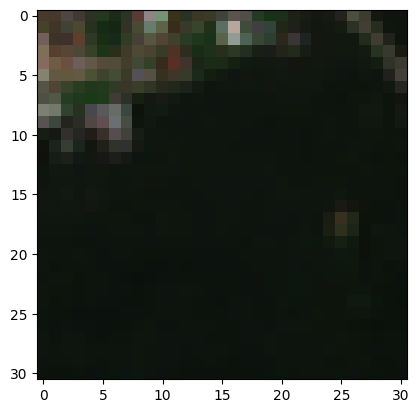

In [85]:
plt.imshow(rgg_hw_c)

In [ ]:
patches_path = PROJECT_ROOT / "outputs/15px_patches" / "combined_15px_patches.geojson"

with open(patches_path, "r") as f:
    patches = json.load(f)

B2 = patches["features"][1245]["properties"]["B2"]
G2 = patches["features"][4]["properties"]["B3"]
R2 = patches["features"][460]["properties"]["B2"]


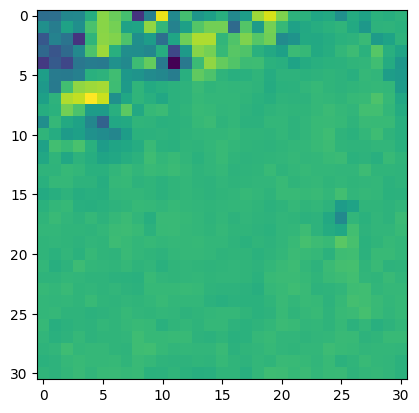

In [100]:
diff_GR = np.subtract(G, R)

plt.imshow(diff_GR)